In [141]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

**KO delayed model tuning analysis**

In [301]:
tuning_results = pd.read_csv('/data/users/sofia/england/TwoTowers/twotowe_opt1_2704/KOdelayed_tuning/gridsearch_results.csv').set_index('trial')

In [302]:
tuning_results

,patience,delta,proj_dim,proj_ko_dim,dropout_emb,dropout_ko,lr,wd,label_smoothing,detach_ko_epochs,batch_size,best_epoch,best_val_f1,test_loss,test_acc,test_f1,test_prec
trial,,,,,,,,,,,,,,,,,
1622,15,0.001,64,64,0.1,0.2,0.00010,0.010,0.01,10,144,41,0.848736,0.440139,0.863073,0.859869,0.860981
741,10,0.001,64,64,0.2,0.2,0.00010,0.010,0.01,5,144,41,0.850626,0.444570,0.860595,0.858436,0.858723
1020,15,0.001,256,64,0.1,0.4,0.00010,0.010,0.01,3,144,48,0.848562,0.446194,0.860595,0.856489,0.857984
1063,15,0.001,256,64,0.2,0.2,0.00010,0.010,0.01,15,144,42,0.843834,0.432777,0.861214,0.856480,0.855643
641,10,0.001,64,64,0.1,0.2,0.00003,0.010,0.01,5,144,77,0.840939,0.471542,0.859356,0.856324,0.858145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,10,0.001,256,32,0.1,0.4,0.00003,0.001,0.01,25,144,93,0.785385,0.519488,0.795539,0.788013,0.787219
254,10,0.001,256,32,0.2,0.2,0.00003,0.001,0.01,25,144,72,0.782327,0.520222,0.792441,0.785295,0.785867
1212,15,0.001,256,32,0.2,0.2,0.00003,0.001,0.01,10,144,65,0.787694,0.513584,0.788724,0.783366,0.779843


In [4]:
results_on_validation_set = pd.read_csv('/data/users/sofia/england/TwoTowers/twotowe_opt1_2704/KOdelayed_tuning/trial_summary_on_VALset.csv').set_index('trial')

In [18]:
results_on_validation_set[['val_loss','val_acc','val_f1']].describe()

,val_loss,val_acc,val_f1
count,1920.000000,1920.000000,1920.000000
mean,0.505993,0.836093,0.832153
std,0.035975,0.013670,0.015419
min,0.440900,0.786200,0.779000
25%,0.469000,0.828400,0.822575
50%,0.516750,0.840100,0.836600
75%,0.531900,0.846300,0.844400
max,0.591200,0.858100,0.856300


**Choose best model**

In [16]:
lowest_val_loss = results_on_validation_set.loc[results_on_validation_set['val_loss'] == results_on_validation_set['val_loss'].min()]
highest_val_f1 = results_on_validation_set.loc[results_on_validation_set['val_f1'] == results_on_validation_set['val_f1'].max()]

In [20]:
highest_val_f1

,best_epoch,val_loss,val_acc,val_f1,patience,delta,proj_dim,proj_ko_dim,dropout_emb,dropout_ko,lr,wd,label_smoothing,detach_ko_epochs,batch_size
trial,,,,,,,,,,,,,,,
997,41,0.5132,0.8575,0.8563,15,0.001,256,64,0.1,0.2,0.0001,0.001,0.05,10,144


In [19]:
lowest_val_loss

,best_epoch,val_loss,val_acc,val_f1,patience,delta,proj_dim,proj_ko_dim,dropout_emb,dropout_ko,lr,wd,label_smoothing,detach_ko_epochs,batch_size
trial,,,,,,,,,,,,,,,
784,45,0.4409,0.8501,0.8484,10,0.001,64,64,0.2,0.4,0.0001,0.01,0.01,25,144


In [6]:
merged = results_on_validation_set.merge(tuning_results, left_index = True, right_index = True)

In [21]:
def check_consistency(df):
    xs = sorted([i for i in df.columns if '_x' in i])
    ys = sorted([i for i in df.columns if '_y' in i])
    for x,y in zip(xs, ys):
        if df.loc[df[x] != df[y]].shape[0] != 0:
            print(df.loc[df[x] != df[y]])
    if df.loc[round(df['val_f1'],4) != round(df['best_val_f1'],4)].shape[0] != 0:
        print(df.loc[df['val_f1'] != df['best_val_f1']][['val_f1', 'best_val_f1']])
        

In [22]:
check_consistency(merged)

In [23]:
merged.sort_values(by = 'val_loss')

,best_epoch_x,val_loss,val_acc,val_f1,patience_x,delta_x,proj_dim_x,proj_ko_dim_x,dropout_emb_x,dropout_ko_x,...,wd_y,label_smoothing_y,detach_ko_epochs_y,batch_size_y,best_epoch_y,best_val_f1,test_loss,test_acc,test_f1,test_prec
trial,,,,,,,,,,,,,,,,,,,,,
784,45,0.4409,0.8501,0.8484,10,0.001,64,64,0.2,0.4,...,0.010,0.01,25,144,45,0.848423,0.436219,0.840768,0.838185,0.833836
664,54,0.4411,0.8488,0.8462,10,0.001,64,64,0.1,0.2,...,0.010,0.01,25,144,54,0.846182,0.447468,0.849442,0.845089,0.841786
1064,42,0.4441,0.8395,0.8381,15,0.001,256,64,0.2,0.2,...,0.010,0.01,25,144,42,0.838122,0.446945,0.828377,0.825675,0.820192
1102,45,0.4453,0.8463,0.8442,15,0.001,256,64,0.2,0.4,...,0.010,0.01,10,144,45,0.844156,0.429535,0.850682,0.848204,0.845699
64,45,0.4456,0.8408,0.8389,10,0.001,256,64,0.1,0.4,...,0.010,0.01,25,144,45,0.838855,0.432104,0.835812,0.831315,0.825341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1498,72,0.5850,0.8024,0.7946,15,0.001,128,32,0.1,0.4,...,0.001,0.05,15,144,72,0.794642,0.519287,0.806072,0.799548,0.797929
1447,91,0.5851,0.8017,0.7949,15,0.001,128,32,0.1,0.2,...,0.010,0.05,10,144,91,0.794919,0.516267,0.809170,0.802396,0.800924
175,62,0.5906,0.7955,0.7884,10,0.001,256,32,0.1,0.2,...,0.001,0.05,3,144,62,0.788385,0.521267,0.797398,0.792169,0.789061


In [24]:
merged.sort_values(by = 'val_f1', ascending = False)

,best_epoch_x,val_loss,val_acc,val_f1,patience_x,delta_x,proj_dim_x,proj_ko_dim_x,dropout_emb_x,dropout_ko_x,...,wd_y,label_smoothing_y,detach_ko_epochs_y,batch_size_y,best_epoch_y,best_val_f1,test_loss,test_acc,test_f1,test_prec
trial,,,,,,,,,,,,,,,,,,,,,
997,41,0.5132,0.8575,0.8563,15,0.001,256,64,0.1,0.2,...,0.001,0.05,10,144,41,0.856334,0.441452,0.850062,0.847625,0.845353
996,39,0.5131,0.8575,0.8562,15,0.001,256,64,0.1,0.2,...,0.001,0.05,5,144,39,0.856166,0.452447,0.846964,0.843477,0.844120
795,30,0.5177,0.8569,0.8559,10,0.001,64,64,0.2,0.4,...,0.001,0.05,3,144,30,0.855881,0.459581,0.846964,0.843341,0.841713
1669,42,0.5201,0.8581,0.8558,15,0.001,64,64,0.1,0.4,...,0.010,0.05,25,144,42,0.855759,0.444674,0.847584,0.843638,0.843593
1392,41,0.4541,0.8581,0.8553,15,0.001,128,64,0.2,0.2,...,0.001,0.01,10,144,41,0.855347,0.444499,0.858736,0.856206,0.858053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,72,0.5364,0.7943,0.7877,10,0.001,256,32,0.1,0.2,...,0.010,0.01,3,144,72,0.787686,0.515062,0.798017,0.791821,0.791161
1212,65,0.5320,0.7943,0.7877,15,0.001,256,32,0.2,0.2,...,0.001,0.01,10,144,65,0.787694,0.513584,0.788724,0.783366,0.779843
214,93,0.5416,0.7931,0.7854,10,0.001,256,32,0.1,0.4,...,0.001,0.01,25,144,93,0.785385,0.519488,0.795539,0.788013,0.787219


In [72]:
merged_performances = merged[['val_loss', 'val_acc', 'val_f1', 'test_loss', 'test_acc', 'test_f1']]
merged_performances['trial'] = merged_performances.index
merged_performances = pd.melt(merged_performances, id_vars= 'trial')
merged_performances[['set','metric']] = merged_performances['variable'].str.split('_', n=1, expand=True)
merged_performances['set'] = merged_performances['set'].str.capitalize()

/tmp/ipykernel_639355/2206955014.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_performances['trial'] = merged_performances.index


In [85]:
lowest_val_loss.index.unique().tolist()[0]

784

In [86]:
merged_performances.loc[merged_performances['trial'] == lowest_val_loss.index.unique().tolist()[0]]

,trial,variable,value,set,metric
784,784,val_loss,0.440900,Val,loss
2704,784,val_acc,0.850100,Val,acc
4624,784,val_f1,0.848400,Val,f1
6544,784,test_loss,0.436219,Test,loss
8464,784,test_acc,0.840768,Test,acc
10384,784,test_f1,0.838185,Test,f1


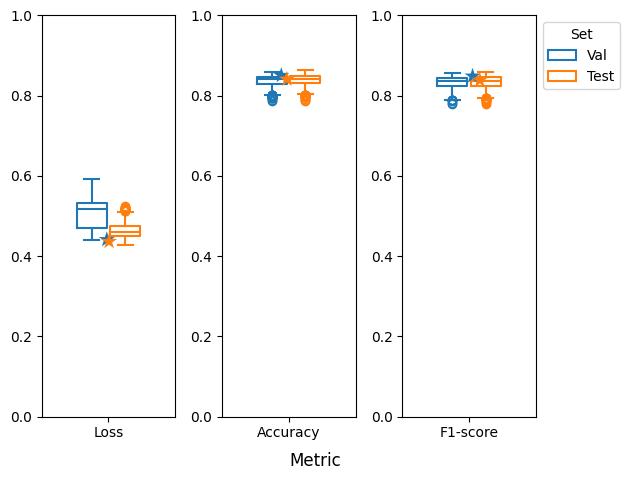

In [346]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)
sns.boxplot(data = merged_performances.loc[merged_performances['metric'] == 'loss'], y = 'value', x = 'metric', hue = 'set', ax = ax1,width =.5, fill = False, legend = None, gap=.1)
sns.stripplot(data = merged_performances.loc[(merged_performances['trial'] == lowest_val_loss.index.unique().tolist()[0])&(merged_performances['metric'] == 'loss')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax1, legend = None)
sns.boxplot(data = merged_performances.loc[merged_performances['metric'] == 'acc'], y = 'value', x = 'metric', hue = 'set', ax = ax2, width =.5, fill = False, legend = None, gap=.1)
sns.stripplot(data = merged_performances.loc[(merged_performances['trial'] == lowest_val_loss.index.unique().tolist()[0])&(merged_performances['metric'] == 'acc')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax2, legend = None)
sns.boxplot(data = merged_performances.loc[merged_performances['metric'] == 'f1'], y = 'value', x = 'metric', hue = 'set', ax = ax3, width =.5, fill = False, gap=.1)
sns.stripplot(data = merged_performances.loc[(merged_performances['trial'] == lowest_val_loss.index.unique().tolist()[0])&(merged_performances['metric'] == 'f1')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax3, legend = None)
ax1.set_ylabel('')
ax2.set_ylabel('')
ax3.set_ylabel('')
ax1.set_ylim(0,1)
ax2.set_ylim(0,1)
ax3.set_ylim(0,1)
ax3.legend(bbox_to_anchor = (1,1), title = 'Set')
plt.tight_layout()
ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('')
f.supxlabel('Metric')
ax1.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax2.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax3.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax1.set_xticks(labels=['Loss'], ticks = [0])
ax1.tick_params(which = 'major', labelsize = 10, axis = 'x')
ax2.set_xticks(labels=['Accuracy'], ticks = [0])
ax2.tick_params(which = 'major', labelsize = 10, axis = 'x')
ax3.set_xticks(labels=['F1-score'], ticks = [0])
ax3.tick_params(which = 'major', labelsize = 10, axis = 'x')

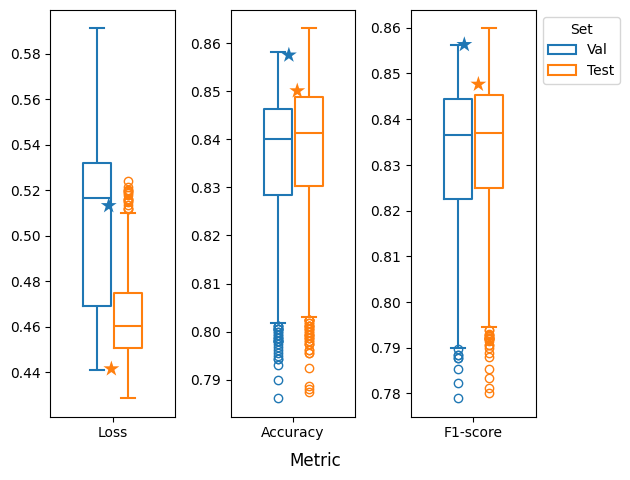

In [104]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)
sns.boxplot(data = merged_performances.loc[merged_performances['metric'] == 'loss'], y = 'value', x = 'metric', hue = 'set', ax = ax1,width =.5, fill = False, legend = None, gap=.1)
sns.stripplot(data = merged_performances.loc[(merged_performances['trial'] == highest_val_f1.index.unique().tolist()[0])&(merged_performances['metric'] == 'loss')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax1, legend = None)
sns.boxplot(data = merged_performances.loc[merged_performances['metric'] == 'acc'], y = 'value', x = 'metric', hue = 'set', ax = ax2, width =.5, fill = False, legend = None, gap=.1)
sns.stripplot(data = merged_performances.loc[(merged_performances['trial'] == highest_val_f1.index.unique().tolist()[0])&(merged_performances['metric'] == 'acc')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax2, legend = None)
sns.boxplot(data = merged_performances.loc[merged_performances['metric'] == 'f1'], y = 'value', x = 'metric', hue = 'set', ax = ax3, width =.5, fill = False, gap=.1)
sns.stripplot(data = merged_performances.loc[(merged_performances['trial'] == highest_val_f1.index.unique().tolist()[0])&(merged_performances['metric'] == 'f1')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax3, legend = None)
ax1.set_ylabel('')
ax2.set_ylabel('')
ax3.set_ylabel('')
ax3.legend(bbox_to_anchor = (1,1), title = 'Set')
plt.tight_layout()
ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('')
f.supxlabel('Metric')
ax1.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax2.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax3.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax1.set_xticks(labels=['Loss'], ticks = [0])
ax1.tick_params(which = 'major', labelsize = 10, axis = 'x')
ax2.set_xticks(labels=['Accuracy'], ticks = [0])
ax2.tick_params(which = 'major', labelsize = 10, axis = 'x')
ax3.set_xticks(labels=['F1-score'], ticks = [0])
ax3.tick_params(which = 'major', labelsize = 10, axis = 'x')

Hyperparameter selection was primarily based on validation macro F1 score, as this metric better reflected balanced multiclass classification performance across environmental categories. Validation loss was monitored as a secondary optimization indicator.

In [ ]:
f1_scores = tuning_results[['best_val_f1', 'test_f1']]
f1_scores.columns = ['Validation', 'Test']

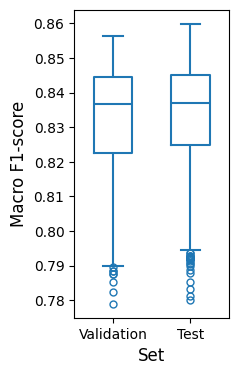

In [51]:
plt.figure(figsize = (2,4))
sns.boxplot(data = pd.melt(f1_scores), y = 'value', x = 'variable', width =.5, fliersize = 5, fill = False)
plt.xlabel('Set', size = 12)
plt.ylabel('Macro F1-score', size = 12)
plt.tick_params(which = 'major', axis = 'both', labelsize = 10)

Test performances

Text(0.5, 0.98, 'Performance on test set')

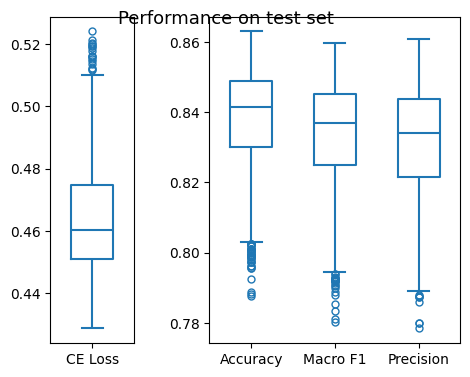

In [56]:
test_performances = tuning_results[[i for i in tuning_results.columns if 'test' in i]]
test_performances.columns = ['CE Loss', 'Accuracy', 'Macro F1', 'Precision']
f, (ax1, ax2) = plt.subplots(1,2, gridspec_kw = {'width_ratios': [1,3]}, figsize = (5,4))
sns.boxplot(data = pd.melt(test_performances).loc[pd.melt(test_performances)['variable'] == 'CE Loss'], y = 'value', x = 'variable', ax = ax1, width =.5, fill = False,fliersize = 5)
sns.boxplot(data = pd.melt(test_performances).loc[pd.melt(test_performances)['variable'] != 'CE Loss'], y = 'value', x = 'variable', ax = ax2, width =.5, fill = False,fliersize = 5)
plt.tight_layout()
ax1.set_xlabel('')
ax1.set_ylabel('')
ax2.set_ylabel('')
ax2.set_xlabel('')
ax1.tick_params(which = 'major', axis = 'both', labelsize = 10)
ax2.tick_params(which = 'major', axis = 'both', labelsize = 10)
f.suptitle('Performance on test set', size = 13)

**Hyperparameter Analysis**

In [100]:
results_on_validation_set.describe()

,best_epoch,val_loss,val_acc,val_f1,patience,delta,proj_dim,proj_ko_dim,dropout_emb,dropout_ko,lr,wd,label_smoothing,detach_ko_epochs,batch_size
count,1920.000000,1920.000000,1920.000000,1920.000000,1920.000000,1.920000e+03,1920.000000,1920.000000,1920.000000,1920.000000,1920.000000,1920.000000,1920.000000,1920.000000,1920.0
mean,67.875000,0.505993,0.836093,0.832153,12.500000,1.000000e-03,149.333333,48.000000,0.150000,0.300000,0.000065,0.005500,0.030000,11.600000,144.0
std,25.293133,0.035975,0.013670,0.015419,2.500651,4.337939e-19,79.842819,16.004168,0.050013,0.100026,0.000035,0.004501,0.020005,7.891288,0.0
min,25.000000,0.440900,0.786200,0.779000,10.000000,1.000000e-03,64.000000,32.000000,0.100000,0.200000,0.000030,0.001000,0.010000,3.000000,144.0
25%,44.000000,0.469000,0.828400,0.822575,10.000000,1.000000e-03,64.000000,32.000000,0.100000,0.200000,0.000030,0.001000,0.010000,5.000000,144.0
50%,66.000000,0.516750,0.840100,0.836600,12.500000,1.000000e-03,128.000000,48.000000,0.150000,0.300000,0.000065,0.005500,0.030000,10.000000,144.0
75%,90.000000,0.531900,0.846300,0.844400,15.000000,1.000000e-03,256.000000,64.000000,0.200000,0.400000,0.000100,0.010000,0.050000,15.000000,144.0
max,138.000000,0.591200,0.858100,0.856300,15.000000,1.000000e-03,256.000000,64.000000,0.200000,0.400000,0.000100,0.010000,0.050000,25.000000,144.0


Text(0.5, 1.0, 'Patience')

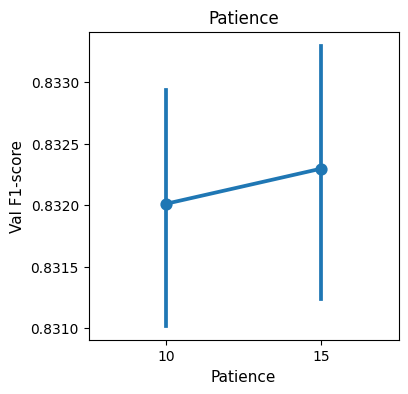

In [124]:
#Patience
plt.figure(figsize=(4,4))
sns.pointplot(data = results_on_validation_set, x = 'patience', y = 'val_f1', errorbar='ci')
plt.tick_params(axis = 'both', which = 'major', labelsize = 10)
plt.ylabel('Val F1-score', size = 11)
plt.xlabel('Patience', size = 11)
plt.title('Patience')

In [144]:
st.spearmanr(results_on_validation_set['patience'],results_on_validation_set['val_f1'])

SignificanceResult(statistic=np.float64(0.010524669731689796), pvalue=np.float64(0.6448844460471913))

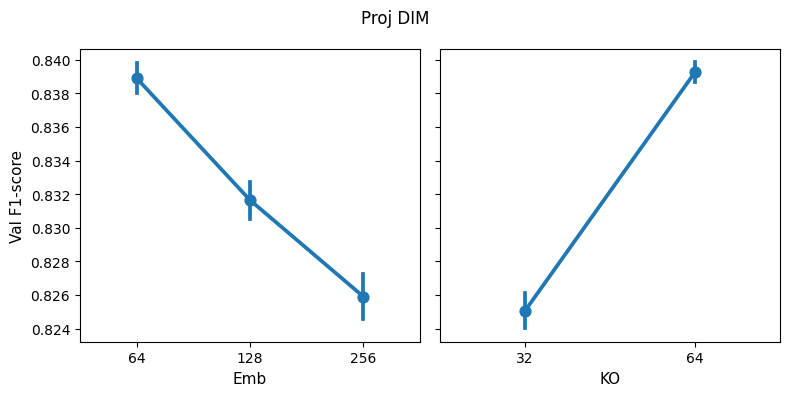

In [127]:
#proj_dim
f, (ax1, ax2) = plt.subplots(1,2, sharey = True, figsize = (8,4))
sns.pointplot(data = results_on_validation_set, x = 'proj_dim', y = 'val_f1', errorbar='ci', ax = ax1)
sns.pointplot(data = results_on_validation_set, x = 'proj_ko_dim', y = 'val_f1', errorbar='ci', ax = ax2)
ax1.tick_params(axis = 'both', which = 'major', labelsize = 10)
ax2.tick_params(axis = 'both', which = 'major', labelsize = 10)
ax1.set_ylabel('Val F1-score', size = 11)
ax1.set_xlabel('Emb', size = 11)
ax2.set_xlabel('KO', size = 11)
f.suptitle('Proj DIM')
plt.tight_layout()

In [146]:
print(st.spearmanr(results_on_validation_set['proj_dim'],results_on_validation_set['val_f1']))
st.spearmanr(results_on_validation_set['proj_ko_dim'],results_on_validation_set['val_f1'])

SignificanceResult(statistic=np.float64(-0.34516176873325466), pvalue=np.float64(7.728086590580451e-55))


SignificanceResult(statistic=np.float64(0.44321921437313194), pvalue=np.float64(3.3402861788692425e-93))

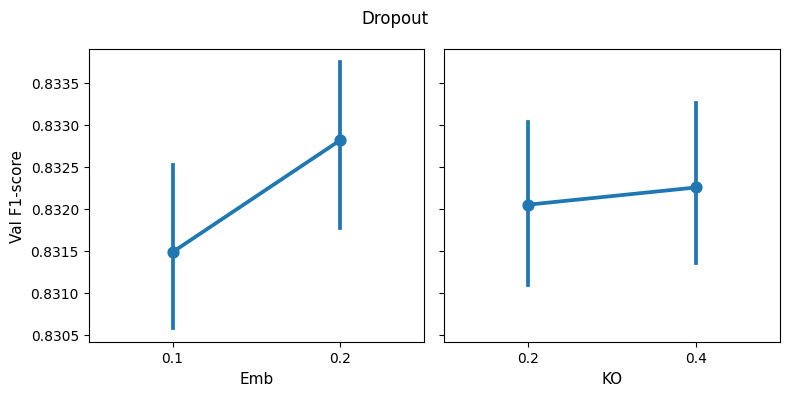

In [128]:
#dropout
f, (ax1, ax2) = plt.subplots(1,2, sharey = True, figsize = (8,4))
sns.pointplot(data = results_on_validation_set, x = 'dropout_emb', y = 'val_f1', errorbar='ci', ax = ax1)
sns.pointplot(data = results_on_validation_set, x = 'dropout_ko', y = 'val_f1', errorbar='ci', ax = ax2)
ax1.tick_params(axis = 'both', which = 'major', labelsize = 10)
ax2.tick_params(axis = 'both', which = 'major', labelsize = 10)
ax1.set_ylabel('Val F1-score', size = 11)
ax1.set_xlabel('Emb', size = 11)
ax2.set_xlabel('KO', size = 11)
f.suptitle('Dropout')
plt.tight_layout()

In [149]:
print(st.spearmanr(results_on_validation_set['dropout_emb'],results_on_validation_set['val_f1']))
st.spearmanr(results_on_validation_set['dropout_ko'],results_on_validation_set['val_f1'])

SignificanceResult(statistic=np.float64(0.04817197718353697), pvalue=np.float64(0.03480318088546445))


SignificanceResult(statistic=np.float64(0.005941739885131659), pvalue=np.float64(0.7947197307328182))

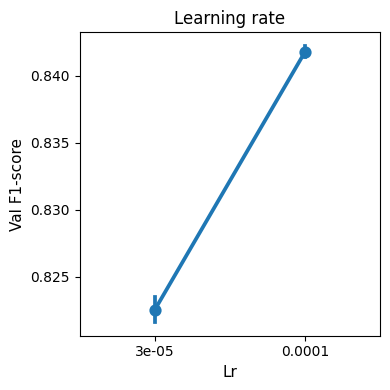

In [137]:
#Lr
plt.figure(figsize=(4,4))
sns.pointplot(data = results_on_validation_set, x = 'lr', y = 'val_f1', errorbar='ci')
#plt.xscale('log')
plt.tick_params(axis = 'both', which = 'major', labelsize = 10)
plt.ylabel('Val F1-score', size = 11)
plt.xlabel('Lr', size = 11)
plt.title('Learning rate')
plt.tight_layout()

In [150]:
st.spearmanr(results_on_validation_set['lr'],results_on_validation_set['val_f1'])

SignificanceResult(statistic=np.float64(0.6199190221416575), pvalue=np.float64(2.9720456028749244e-204))

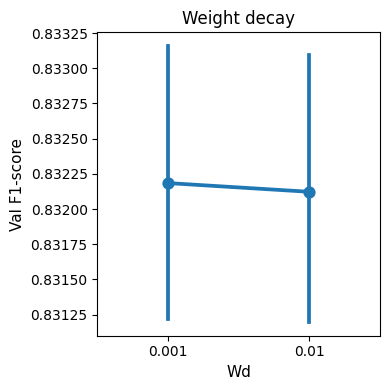

In [140]:
#wd
plt.figure(figsize=(4,4))
sns.pointplot(data = results_on_validation_set, x = 'wd', y = 'val_f1', errorbar='ci')
#plt.xscale('log')
plt.tick_params(axis = 'both', which = 'major', labelsize = 10)
plt.ylabel('Val F1-score', size = 11)
plt.xlabel('Wd', size = 11)
plt.title('Weight decay')
plt.tight_layout()

In [151]:
st.spearmanr(results_on_validation_set['wd'],results_on_validation_set['val_f1'])

SignificanceResult(statistic=np.float64(0.0010270950014943704), pvalue=np.float64(0.9641266372871178))

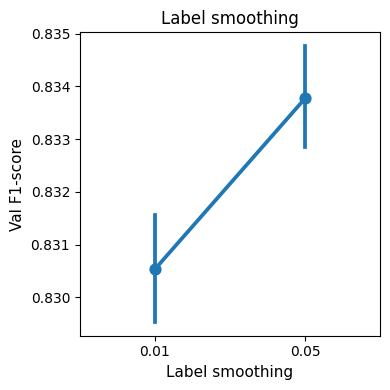

In [154]:
#label smoothing
plt.figure(figsize=(4,4))
sns.pointplot(data = results_on_validation_set, x = 'label_smoothing', y = 'val_f1', errorbar='ci')
#plt.xscale('log')
plt.tick_params(axis = 'both', which = 'major', labelsize = 10)
plt.ylabel('Val F1-score', size = 11)
plt.xlabel('Label smoothing', size = 11)
plt.title('Label smoothing')
plt.tight_layout()

In [155]:
st.spearmanr(results_on_validation_set['label_smoothing'],results_on_validation_set['val_f1'])

SignificanceResult(statistic=np.float64(0.11572908042913008), pvalue=np.float64(3.68042820896051e-07))

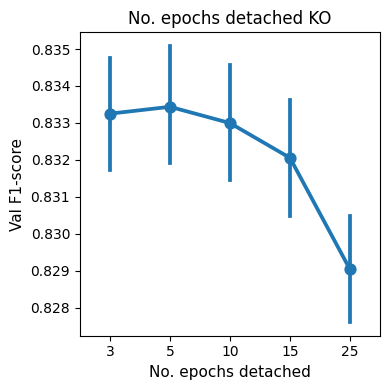

In [156]:
#detach ko epochs
plt.figure(figsize=(4,4))
sns.pointplot(data = results_on_validation_set, x = 'detach_ko_epochs', y = 'val_f1', errorbar='ci')
#plt.xscale('log')
plt.tick_params(axis = 'both', which = 'major', labelsize = 10)
plt.ylabel('Val F1-score', size = 11)
plt.xlabel('No. epochs detached', size = 11)
plt.title('No. epochs detached KO')
plt.tight_layout()

In [157]:
st.spearmanr(results_on_validation_set['detach_ko_epochs'],results_on_validation_set['val_f1'])

SignificanceResult(statistic=np.float64(-0.10991432150198838), pvalue=np.float64(1.381181335675193e-06))

In [176]:
import re

In [198]:
correlation_perf_hp = results_on_validation_set.merge(tuning_results['test_f1'], left_index= True, right_index= True)[['lr', 'proj_ko_dim', 'proj_dim','label_smoothing', 'detach_ko_epochs','dropout_emb','dropout_ko','patience', 'wd','val_f1','test_f1']].corr(method = 'spearman')[['val_f1','test_f1']].drop(['val_f1', 'test_f1'])
correlation_perf_hp.index = [re.sub('_',' ',i).capitalize() for i in correlation_perf_hp.index]
correlation_perf_hp.columns = ['Val F1', 'Test F1']

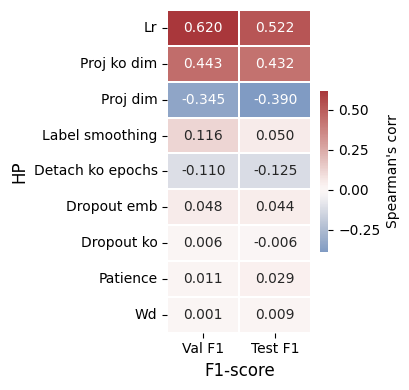

In [200]:
plt.figure(figsize=(4,4))
sns.heatmap(correlation_perf_hp, annot = True, fmt = '.3f',center = 0, cmap = sns.color_palette('vlag', as_cmap= True), linewidths=.1, cbar_kws={'shrink':.5, 'label':"Spearman's corr"})
plt.xlabel('F1-score', size = 12)
plt.ylabel('HP', size = 12)
plt.tight_layout()

HP interactions

In [339]:
hps_f1s = results_on_validation_set.merge(tuning_results['test_f1'], left_index= True, right_index= True)[['lr', 'proj_ko_dim', 'proj_dim','label_smoothing', 'detach_ko_epochs','dropout_emb','dropout_ko','patience', 'wd','val_f1','test_f1']]

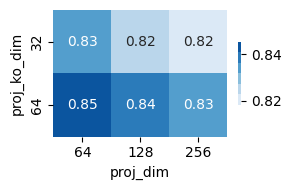

In [221]:
pivot = hps_f1s.pivot_table(
    values="val_f1",
    index="proj_ko_dim",
    columns="proj_dim",
    aggfunc="mean"
)
plt.figure(figsize=(3,2))
sns.heatmap(pivot, annot=True, cmap =sns.color_palette('Blues'),cbar_kws = {'shrink':.5})
plt.tight_layout()

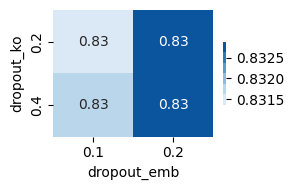

In [223]:
pivot = hps_f1s.pivot_table(
    values="val_f1",
    index="dropout_ko",
    columns="dropout_emb",
    aggfunc="mean"
)
plt.figure(figsize=(3,2))
sns.heatmap(pivot, annot=True, cmap =sns.color_palette('Blues'),cbar_kws = {'shrink':.5})
plt.tight_layout()

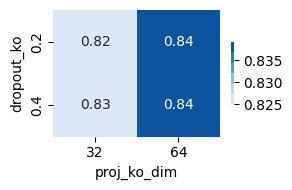

In [224]:
pivot = hps_f1s.pivot_table(
    values="val_f1",
    index="dropout_ko",
    columns="proj_ko_dim",
    aggfunc="mean"
)
plt.figure(figsize=(3,2))
sns.heatmap(pivot, annot=True, cmap =sns.color_palette('Blues'),cbar_kws = {'shrink':.5})
plt.tight_layout()

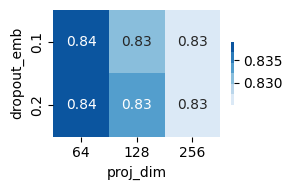

In [225]:
pivot = hps_f1s.pivot_table(
    values="val_f1",
    index="dropout_emb",
    columns="proj_dim",
    aggfunc="mean"
)
plt.figure(figsize=(3,2))
sns.heatmap(pivot, annot=True, cmap =sns.color_palette('Blues'),cbar_kws = {'shrink':.5})
plt.tight_layout()

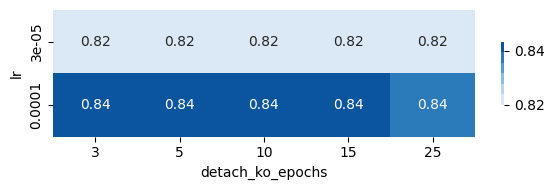

In [228]:
pivot = hps_f1s.pivot_table(
    values="val_f1",
    index="lr",
    columns="detach_ko_epochs",
    aggfunc="mean"
)
plt.figure(figsize=(6,2))
sns.heatmap(pivot, annot=True, cmap =sns.color_palette('Blues'),cbar_kws = {'shrink':.5})
plt.tight_layout()

Chosen model = highest_val_f1

In [230]:
highest_val_f1

,best_epoch,val_loss,val_acc,val_f1,patience,delta,proj_dim,proj_ko_dim,dropout_emb,dropout_ko,lr,wd,label_smoothing,detach_ko_epochs,batch_size
trial,,,,,,,,,,,,,,,
997,41,0.5132,0.8575,0.8563,15,0.001,256,64,0.1,0.2,0.0001,0.001,0.05,10,144


In [344]:
tuning_results.loc[997]

patience             15.000000
delta                 0.001000
proj_dim            256.000000
proj_ko_dim          64.000000
dropout_emb           0.100000
dropout_ko            0.200000
lr                    0.000100
wd                    0.001000
label_smoothing       0.050000
detach_ko_epochs     10.000000
batch_size          144.000000
best_epoch           41.000000
best_val_f1           0.856334
test_loss             0.441452
test_acc              0.850062
test_f1               0.847625
test_prec             0.845353
Name: 997, dtype: float64

In [343]:
lowest_val_loss_New

,best_epoch,val_loss,val_acc,val_f1,patience,delta,proj_dim,proj_ko_dim,dropout_emb,dropout_ko,lr,wd,label_smoothing,detach_ko_epochs,batch_size
trial,,,,,,,,,,,,,,,
90,33,0.5299,0.8155,0.8157,15,0.001,64,64,0.1,0.2,0.0001,0.001,0.01,3,144


In [345]:
tuning_results_New.loc[90]

patience             15.000000
delta                 0.001000
proj_dim             64.000000
proj_ko_dim          64.000000
dropout_emb           0.100000
dropout_ko            0.200000
lr                    0.000100
wd                    0.001000
label_smoothing       0.010000
detach_ko_epochs      3.000000
batch_size          144.000000
best_epoch           33.000000
best_val_f1           0.815683
test_loss             0.461686
test_acc              0.845105
test_f1               0.844342
test_prec             0.846268
Name: 90, dtype: float64

Launching chosen model on new splits with different seeds... : run_delayed_Seeds.py

In [245]:
seeds_analysis = pd.read_csv('/data/users/sofia/england/TwoTowers/delayed_KOChosen_usualSplits_seedsLog/summary_results.csv')

In [274]:
seeds_analysis.describe()

,Seed,Best_epoch,Train_Loss,Train_F1,Train_Acc,Val_Loss,Val_F1,Val_Acc,Val_Prec,Test_Loss,Test_F1,Test_Acc,Test_Prec
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,160.800000,37.933333,0.268973,0.996780,0.996967,0.525244,0.844553,0.846507,0.846327,0.449195,0.843368,0.846964,0.842114
std,274.553716,6.374802,0.016538,0.002609,0.002387,0.003595,0.003144,0.003323,0.005969,0.007549,0.005617,0.005561,0.007326
min,0.000000,28.000000,0.243118,0.990600,0.991600,0.520096,0.837100,0.838300,0.832800,0.433560,0.832506,0.835192,0.827678
25%,13.500000,33.000000,0.260100,0.994700,0.995000,0.523232,0.842650,0.845100,0.842850,0.444958,0.839759,0.843866,0.837844
50%,25.000000,38.000000,0.263638,0.998000,0.997900,0.525876,0.845800,0.847600,0.848900,0.446533,0.842054,0.846344,0.840912
75%,187.500000,42.500000,0.276604,0.998800,0.998800,0.526512,0.846850,0.848500,0.850250,0.456890,0.845866,0.849753,0.847413
max,1024.000000,52.000000,0.310110,0.999500,0.999600,0.535463,0.849400,0.850700,0.853800,0.458825,0.855259,0.858116,0.855260


<Axes: xlabel='Best_epoch'>

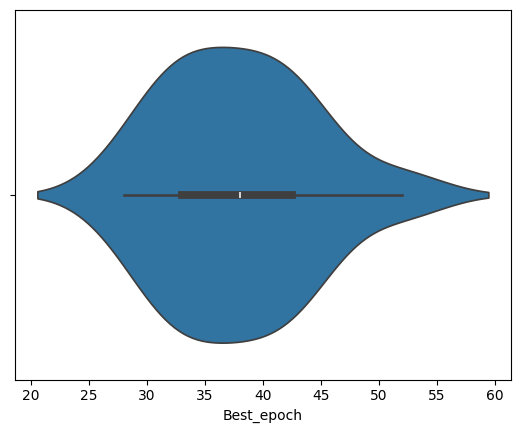

In [246]:
sns.violinplot(data = seeds_analysis, x  = 'Best_epoch')

In [248]:
seeds_analysis_melted = pd.melt(seeds_analysis.drop('Best_epoch', axis = 1), id_vars = ['Seed'])
seeds_analysis_melted[['set','metric']] = seeds_analysis_melted['variable'].str.split('_', n=1, expand=True)

In [251]:
seeds_analysis_melted

,Seed,variable,value,set,metric
0,0,Train_Loss,0.260630,Train,Loss
1,1,Train_Loss,0.283373,Train,Loss
2,5,Train_Loss,0.270919,Train,Loss
3,12,Train_Loss,0.255197,Train,Loss
4,15,Train_Loss,0.243118,Train,Loss
...,...,...,...,...,...
160,150,Test_Prec,0.847039,Test,Prec
161,225,Test_Prec,0.838431,Test,Prec
162,333,Test_Prec,0.834185,Test,Prec
163,444,Test_Prec,0.835355,Test,Prec


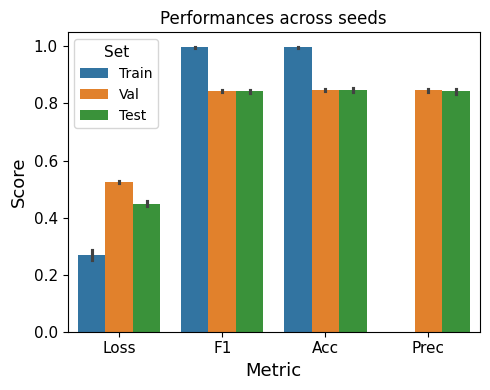

In [268]:
plt.figure(figsize = (5,4))
sns.barplot(data = seeds_analysis_melted, y = 'value', x = 'metric', errorbar='sd', hue = 'set')
plt.xlabel('Metric', size = 13)
plt.ylabel('Score', size = 13)
plt.tick_params(which = 'major', axis = 'both', labelsize = 11)
plt.legend(title = 'Set', title_fontsize=11)
plt.title('Performances across seeds')
plt.tight_layout()

Launching chosen model on Mikael splits: /data/users/sofia/england/TwoTowers/delayed_KO_MikaelSplitsProva/log.txt

In [282]:
performances_MikaelSplits = pd.melt(pd.read_csv('/data/users/sofia/england/TwoTowers/delayed_KO_MikaelSplitsProva/summary_results.csv'), id_vars = ['Seed'])
print(performances_MikaelSplits.describe())
performances_MikaelSplits[['set','metric']] = performances_MikaelSplits['variable'].str.split('_', n=1, expand=True)
performances_MikaelSplits.drop(0, inplace = True)
performances_MikaelSplits

       Seed      value
count  12.0  12.000000
mean   42.0   2.766999
std     0.0   7.004028
min    42.0   0.342777
25%    42.0   0.737522
50%    42.0   0.804065
75%    42.0   0.863618
max    42.0  25.000000


,Seed,variable,value,set,metric
1,42,Train_Loss,0.342777,Train,Loss
2,42,Train_F1,0.971200,Train,F1
3,42,Train_Acc,0.973800,Train,Acc
4,42,Val_Loss,0.605588,Val,Loss
5,42,Val_F1,0.785900,Val,F1
6,42,Val_Acc,0.787000,Val,Acc
7,42,Val_Prec,0.781500,Val,Prec
8,42,Test_Loss,0.482834,Test,Loss
9,42,Test_F1,0.824506,Test,F1
10,42,Test_Acc,0.827757,Test,Acc


<Axes: xlabel='metric', ylabel='value'>

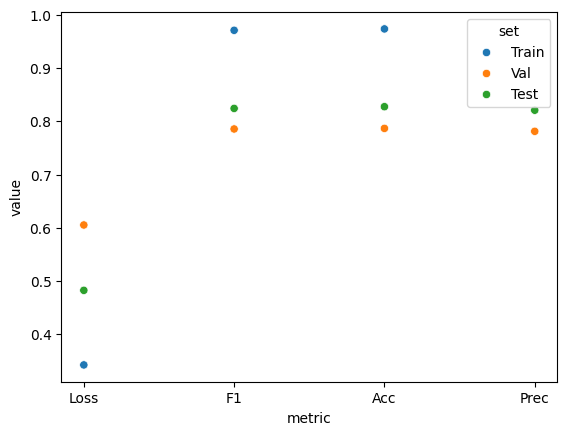

In [289]:
sns.scatterplot(data = performances_MikaelSplits, y = 'value', x = 'metric', hue = 'set') 

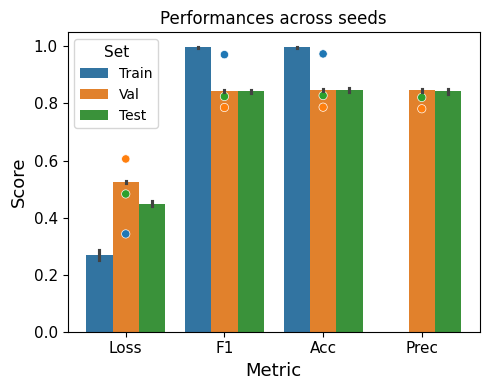

In [297]:
plt.figure(figsize = (5,4))
sns.barplot(data = seeds_analysis_melted, y = 'value', x = 'metric', errorbar='sd', hue = 'set')
sns.scatterplot(data = performances_MikaelSplits, y = 'value', x = 'metric', hue = 'set', legend=None) 
plt.xlabel('Metric', size = 13)
plt.ylabel('Score', size = 13)
plt.tick_params(which = 'major', axis = 'both', labelsize = 11)
plt.legend(title = 'Set', title_fontsize=11)
plt.title('Performances across seeds')
plt.tight_layout()

Launching tuning on Mikael splits (consireding already chosen wd, patience and dropouts)

In [299]:
tuning_results_New = pd.read_csv('/data/users/sofia/england/TwoTowers/twotowe_opt1_2704/KOdelayed_tuning_Newsplits/gridsearch_results.csv').set_index('trial')

In [300]:
tuning_results_New

,patience,delta,proj_dim,proj_ko_dim,dropout_emb,dropout_ko,lr,wd,label_smoothing,detach_ko_epochs,batch_size,best_epoch,best_val_f1,test_loss,test_acc,test_f1,test_prec
trial,,,,,,,,,,,,,,,,,
92,15,0.001,64,64,0.1,0.2,0.00010,0.001,0.01,10,144,39,0.812788,0.454226,0.847584,0.846811,0.850371
95,15,0.001,64,64,0.1,0.2,0.00010,0.001,0.05,3,144,22,0.811109,0.482242,0.845725,0.845042,0.845421
90,15,0.001,64,64,0.1,0.2,0.00010,0.001,0.01,3,144,33,0.815683,0.461686,0.845105,0.844342,0.846268
93,15,0.001,64,64,0.1,0.2,0.00010,0.001,0.01,15,144,30,0.802272,0.455444,0.845105,0.844116,0.846055
91,15,0.001,64,64,0.1,0.2,0.00010,0.001,0.01,5,144,33,0.813523,0.454861,0.844486,0.843195,0.843795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,15,0.001,256,32,0.1,0.2,0.00003,0.001,0.05,3,144,89,0.740239,0.560678,0.770756,0.761925,0.778183
27,15,0.001,256,32,0.1,0.2,0.00003,0.001,0.05,10,144,77,0.744458,0.569206,0.761462,0.752487,0.768180
20,15,0.001,256,32,0.1,0.2,0.00003,0.001,0.01,3,144,75,0.733805,0.577928,0.760223,0.749608,0.770099


In [303]:
results_on_validation_set_New = pd.read_csv('/data/users/sofia/england/TwoTowers/twotowe_opt1_2704/KOdelayed_tuning_Newsplits/trial_summary_on_VALset.csv').set_index('trial')

In [304]:
results_on_validation_set_New[['val_loss','val_acc','val_f1']].describe()

,val_loss,val_acc,val_f1
count,120.000000,120.000000,120.000000
mean,0.584030,0.788254,0.785826
std,0.033105,0.018004,0.020757
min,0.529900,0.738700,0.730400
25%,0.551800,0.778975,0.773750
50%,0.591600,0.790400,0.787850
75%,0.610600,0.803700,0.802575
max,0.657800,0.816700,0.817700


**Choose new best model**

In [305]:
lowest_val_loss_New = results_on_validation_set_New.loc[results_on_validation_set_New['val_loss'] == results_on_validation_set_New['val_loss'].min()]
highest_val_f1_New = results_on_validation_set_New.loc[results_on_validation_set_New['val_f1'] == results_on_validation_set_New['val_f1'].max()]

In [308]:
highest_val_f1_New

,best_epoch,val_loss,val_acc,val_f1,patience,delta,proj_dim,proj_ko_dim,dropout_emb,dropout_ko,lr,wd,label_smoothing,detach_ko_epochs,batch_size
trial,,,,,,,,,,,,,,,
96,19,0.5968,0.8167,0.8177,15,0.001,64,64,0.1,0.2,0.0001,0.001,0.05,5,144


In [306]:
lowest_val_loss_New

,best_epoch,val_loss,val_acc,val_f1,patience,delta,proj_dim,proj_ko_dim,dropout_emb,dropout_ko,lr,wd,label_smoothing,detach_ko_epochs,batch_size
trial,,,,,,,,,,,,,,,
90,33,0.5299,0.8155,0.8157,15,0.001,64,64,0.1,0.2,0.0001,0.001,0.01,3,144


In [309]:
merged_New = results_on_validation_set_New.merge(tuning_results_New, left_index = True, right_index = True)

In [310]:
def check_consistency(df):
    xs = sorted([i for i in df.columns if '_x' in i])
    ys = sorted([i for i in df.columns if '_y' in i])
    for x,y in zip(xs, ys):
        if df.loc[df[x] != df[y]].shape[0] != 0:
            print(df.loc[df[x] != df[y]])
    if df.loc[round(df['val_f1'],4) != round(df['best_val_f1'],4)].shape[0] != 0:
        print(df.loc[df['val_f1'] != df['best_val_f1']][['val_f1', 'best_val_f1']])
        

In [311]:
check_consistency(merged_New)

In [313]:
merged_New.sort_values(by = 'val_loss')

,best_epoch_x,val_loss,val_acc,val_f1,patience_x,delta_x,proj_dim_x,proj_ko_dim_x,dropout_emb_x,dropout_ko_x,...,wd_y,label_smoothing_y,detach_ko_epochs_y,batch_size_y,best_epoch_y,best_val_f1,test_loss,test_acc,test_f1,test_prec
trial,,,,,,,,,,,,,,,,,,,,,
90,33,0.5299,0.8155,0.8157,15,0.001,64,64,0.1,0.2,...,0.001,0.01,3,144,33,0.815683,0.461686,0.845105,0.844342,0.846268
80,63,0.5325,0.8099,0.8110,15,0.001,64,64,0.1,0.2,...,0.001,0.01,3,144,63,0.810951,0.480677,0.838290,0.836351,0.841848
94,45,0.5334,0.8080,0.8092,15,0.001,64,64,0.1,0.2,...,0.001,0.01,25,144,45,0.809176,0.448318,0.836431,0.834499,0.837487
91,33,0.5346,0.8124,0.8135,15,0.001,64,64,0.1,0.2,...,0.001,0.01,5,144,33,0.813523,0.454861,0.844486,0.843195,0.843795
54,40,0.5349,0.7907,0.7884,15,0.001,128,64,0.1,0.2,...,0.001,0.01,25,144,40,0.788366,0.457444,0.824659,0.821816,0.824556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,78,0.6380,0.7604,0.7536,15,0.001,256,32,0.1,0.2,...,0.001,0.05,5,144,78,0.753595,0.550935,0.774473,0.765824,0.778619
28,71,0.6399,0.7585,0.7522,15,0.001,256,32,0.1,0.2,...,0.001,0.05,15,144,71,0.752184,0.542012,0.777571,0.769811,0.780771
67,71,0.6498,0.7591,0.7526,15,0.001,128,32,0.1,0.2,...,0.001,0.05,10,144,71,0.752617,0.554158,0.777571,0.768588,0.788282


In [314]:
merged.sort_values(by = 'val_f1', ascending = False)

,best_epoch_x,val_loss,val_acc,val_f1,patience_x,delta_x,proj_dim_x,proj_ko_dim_x,dropout_emb_x,dropout_ko_x,...,wd_y,label_smoothing_y,detach_ko_epochs_y,batch_size_y,best_epoch_y,best_val_f1,test_loss,test_acc,test_f1,test_prec
trial,,,,,,,,,,,,,,,,,,,,,
997,41,0.5132,0.8575,0.8563,15,0.001,256,64,0.1,0.2,...,0.001,0.05,10,144,41,0.856334,0.441452,0.850062,0.847625,0.845353
996,39,0.5131,0.8575,0.8562,15,0.001,256,64,0.1,0.2,...,0.001,0.05,5,144,39,0.856166,0.452447,0.846964,0.843477,0.844120
795,30,0.5177,0.8569,0.8559,10,0.001,64,64,0.2,0.4,...,0.001,0.05,3,144,30,0.855881,0.459581,0.846964,0.843341,0.841713
1669,42,0.5201,0.8581,0.8558,15,0.001,64,64,0.1,0.4,...,0.010,0.05,25,144,42,0.855759,0.444674,0.847584,0.843638,0.843593
1392,41,0.4541,0.8581,0.8553,15,0.001,128,64,0.2,0.2,...,0.001,0.01,10,144,41,0.855347,0.444499,0.858736,0.856206,0.858053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,72,0.5364,0.7943,0.7877,10,0.001,256,32,0.1,0.2,...,0.010,0.01,3,144,72,0.787686,0.515062,0.798017,0.791821,0.791161
1212,65,0.5320,0.7943,0.7877,15,0.001,256,32,0.2,0.2,...,0.001,0.01,10,144,65,0.787694,0.513584,0.788724,0.783366,0.779843
214,93,0.5416,0.7931,0.7854,10,0.001,256,32,0.1,0.4,...,0.001,0.01,25,144,93,0.785385,0.519488,0.795539,0.788013,0.787219


In [315]:
merged_performances_New = merged_New[['val_loss', 'val_acc', 'val_f1', 'test_loss', 'test_acc', 'test_f1']]
merged_performances_New['trial'] = merged_performances_New.index
merged_performances_New = pd.melt(merged_performances_New, id_vars= 'trial')
merged_performances_New[['set','metric']] = merged_performances_New['variable'].str.split('_', n=1, expand=True)
merged_performances_New['set'] = merged_performances_New['set'].str.capitalize()

/tmp/ipykernel_639355/3432719811.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_performances_New['trial'] = merged_performances_New.index


In [316]:
lowest_val_loss_New.index.unique().tolist()[0]

90

In [317]:
merged_performances_New.loc[merged_performances_New['trial'] == lowest_val_loss_New.index.unique().tolist()[0]]

,trial,variable,value,set,metric
90,90,val_loss,0.529900,Val,loss
210,90,val_acc,0.815500,Val,acc
330,90,val_f1,0.815700,Val,f1
450,90,test_loss,0.461686,Test,loss
570,90,test_acc,0.845105,Test,acc
690,90,test_f1,0.844342,Test,f1


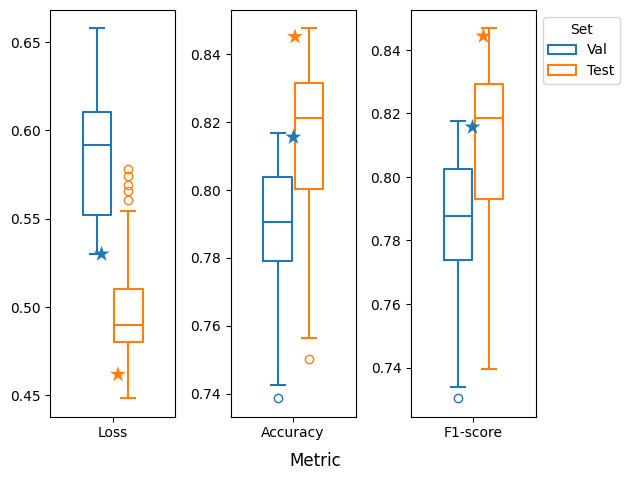

In [365]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)
sns.boxplot(data = merged_performances_New.loc[merged_performances_New['metric'] == 'loss'], y = 'value', x = 'metric', hue = 'set', ax = ax1,width =.5, fill = False, legend = None, gap=.1)
sns.stripplot(data = merged_performances_New.loc[(merged_performances_New['trial'] == lowest_val_loss_New.index.unique().tolist()[0])&(merged_performances_New['metric'] == 'loss')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax1, legend = None)
sns.boxplot(data = merged_performances_New.loc[merged_performances_New['metric'] == 'acc'], y = 'value', x = 'metric', hue = 'set', ax = ax2, width =.5, fill = False, legend = None, gap=.1)
sns.stripplot(data = merged_performances_New.loc[(merged_performances_New['trial'] == lowest_val_loss_New.index.unique().tolist()[0])&(merged_performances_New['metric'] == 'acc')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax2, legend = None)
sns.boxplot(data = merged_performances_New.loc[merged_performances_New['metric'] == 'f1'], y = 'value', x = 'metric', hue = 'set', ax = ax3, width =.5, fill = False, gap=.1)
sns.stripplot(data = merged_performances_New.loc[(merged_performances_New['trial'] == lowest_val_loss_New.index.unique().tolist()[0])&(merged_performances_New['metric'] == 'f1')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax3, legend = None)
ax1.set_ylabel('')
ax2.set_ylabel('')
ax3.set_ylabel('')
ax3.legend(bbox_to_anchor = (1,1), title = 'Set')
plt.tight_layout()
ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('')
#ax1.set_ylim(0,1)
#ax2.set_ylim(0,1)
#ax3.set_ylim(0,1)
f.supxlabel('Metric')
ax1.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax2.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax3.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax1.set_xticks(labels=['Loss'], ticks = [0])
ax1.tick_params(which = 'major', labelsize = 10, axis = 'x')
ax2.set_xticks(labels=['Accuracy'], ticks = [0])
ax2.tick_params(which = 'major', labelsize = 10, axis = 'x')
ax3.set_xticks(labels=['F1-score'], ticks = [0])
ax3.tick_params(which = 'major', labelsize = 10, axis = 'x')

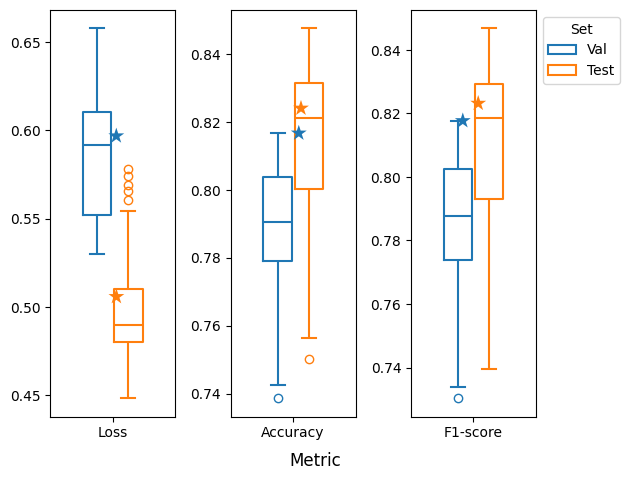

In [319]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)
sns.boxplot(data = merged_performances_New.loc[merged_performances_New['metric'] == 'loss'], y = 'value', x = 'metric', hue = 'set', ax = ax1,width =.5, fill = False, legend = None, gap=.1)
sns.stripplot(data = merged_performances_New.loc[(merged_performances_New['trial'] == highest_val_f1_New.index.unique().tolist()[0])&(merged_performances_New['metric'] == 'loss')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax1, legend = None)
sns.boxplot(data = merged_performances_New.loc[merged_performances_New['metric'] == 'acc'], y = 'value', x = 'metric', hue = 'set', ax = ax2, width =.5, fill = False, legend = None, gap=.1)
sns.stripplot(data = merged_performances_New.loc[(merged_performances_New['trial'] == highest_val_f1_New.index.unique().tolist()[0])&(merged_performances_New['metric'] == 'acc')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax2, legend = None)
sns.boxplot(data = merged_performances_New.loc[merged_performances_New['metric'] == 'f1'], y = 'value', x = 'metric', hue = 'set', ax = ax3, width =.5, fill = False, gap=.1)
sns.stripplot(data = merged_performances_New.loc[(merged_performances_New['trial'] == highest_val_f1_New.index.unique().tolist()[0])&(merged_performances_New['metric'] == 'f1')], y = 'value', x = 'metric', hue = 'set', marker = '*', size = 12, ax = ax3, legend = None)
ax1.set_ylabel('')
ax2.set_ylabel('')
ax3.set_ylabel('')
ax3.legend(bbox_to_anchor = (1,1), title = 'Set')
plt.tight_layout()
ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('')
f.supxlabel('Metric')
ax1.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax2.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax3.tick_params(which = 'major', labelsize = 10, axis = 'y')
ax1.set_xticks(labels=['Loss'], ticks = [0])
ax1.tick_params(which = 'major', labelsize = 10, axis = 'x')
ax2.set_xticks(labels=['Accuracy'], ticks = [0])
ax2.tick_params(which = 'major', labelsize = 10, axis = 'x')
ax3.set_xticks(labels=['F1-score'], ticks = [0])
ax3.tick_params(which = 'major', labelsize = 10, axis = 'x')

In this case I will go with the one with lowest Val loss

In [320]:
f1_scores_New = tuning_results_New[['best_val_f1', 'test_f1']]
f1_scores_New.columns = ['Validation', 'Test']

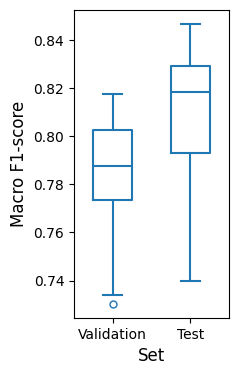

In [321]:
plt.figure(figsize = (2,4))
sns.boxplot(data = pd.melt(f1_scores_New), y = 'value', x = 'variable', width =.5, fliersize = 5, fill = False)
plt.xlabel('Set', size = 12)
plt.ylabel('Macro F1-score', size = 12)
plt.tick_params(which = 'major', axis = 'both', labelsize = 10)

Text(0.5, 0.98, 'Performance on test set')

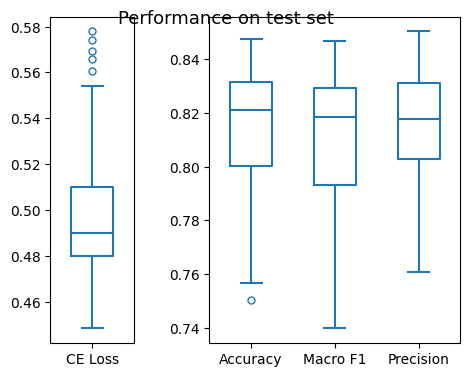

In [322]:
test_performances_New = tuning_results_New[[i for i in tuning_results_New.columns if 'test' in i]]
test_performances_New.columns = ['CE Loss', 'Accuracy', 'Macro F1', 'Precision']
f, (ax1, ax2) = plt.subplots(1,2, gridspec_kw = {'width_ratios': [1,3]}, figsize = (5,4))
sns.boxplot(data = pd.melt(test_performances_New).loc[pd.melt(test_performances_New)['variable'] == 'CE Loss'], y = 'value', x = 'variable', ax = ax1, width =.5, fill = False,fliersize = 5)
sns.boxplot(data = pd.melt(test_performances_New).loc[pd.melt(test_performances_New)['variable'] != 'CE Loss'], y = 'value', x = 'variable', ax = ax2, width =.5, fill = False,fliersize = 5)
plt.tight_layout()
ax1.set_xlabel('')
ax1.set_ylabel('')
ax2.set_ylabel('')
ax2.set_xlabel('')
ax1.tick_params(which = 'major', axis = 'both', labelsize = 10)
ax2.tick_params(which = 'major', axis = 'both', labelsize = 10)
f.suptitle('Performance on test set', size = 13)

**Hyperparameter Analysis**

In [323]:
results_on_validation_set_New.describe()

,best_epoch,val_loss,val_acc,val_f1,patience,delta,proj_dim,proj_ko_dim,dropout_emb,dropout_ko,lr,wd,label_smoothing,detach_ko_epochs,batch_size
count,120.000000,120.000000,120.000000,120.000000,120.0,1.200000e+02,120.000000,120.000000,1.200000e+02,1.200000e+02,120.000000,1.200000e+02,120.000000,120.000000,120.0
mean,58.491667,0.584030,0.788254,0.785826,15.0,1.000000e-03,149.333333,48.000000,1.000000e-01,2.000000e-01,0.000065,1.000000e-03,0.030000,11.600000,144.0
std,23.713272,0.033105,0.018004,0.020757,0.0,4.354992e-19,80.156709,16.067086,1.393598e-17,2.787195e-17,0.000035,4.354992e-19,0.020084,7.922312,0.0
min,19.000000,0.529900,0.738700,0.730400,15.0,1.000000e-03,64.000000,32.000000,1.000000e-01,2.000000e-01,0.000030,1.000000e-03,0.010000,3.000000,144.0
25%,36.000000,0.551800,0.778975,0.773750,15.0,1.000000e-03,64.000000,32.000000,1.000000e-01,2.000000e-01,0.000030,1.000000e-03,0.010000,5.000000,144.0
50%,57.500000,0.591600,0.790400,0.787850,15.0,1.000000e-03,128.000000,48.000000,1.000000e-01,2.000000e-01,0.000065,1.000000e-03,0.030000,10.000000,144.0
75%,78.250000,0.610600,0.803700,0.802575,15.0,1.000000e-03,256.000000,64.000000,1.000000e-01,2.000000e-01,0.000100,1.000000e-03,0.050000,15.000000,144.0
max,108.000000,0.657800,0.816700,0.817700,15.0,1.000000e-03,256.000000,64.000000,1.000000e-01,2.000000e-01,0.000100,1.000000e-03,0.050000,25.000000,144.0


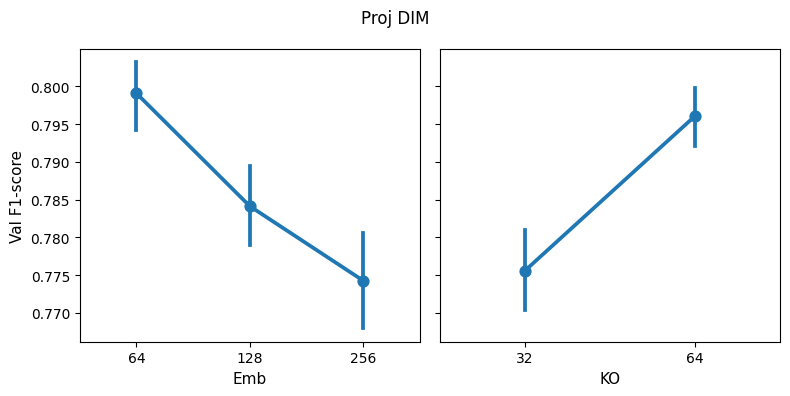

In [325]:
#proj_dim
f, (ax1, ax2) = plt.subplots(1,2, sharey = True, figsize = (8,4))
sns.pointplot(data = results_on_validation_set_New, x = 'proj_dim', y = 'val_f1', errorbar='ci', ax = ax1)
sns.pointplot(data = results_on_validation_set_New, x = 'proj_ko_dim', y = 'val_f1', errorbar='ci', ax = ax2)
ax1.tick_params(axis = 'both', which = 'major', labelsize = 10)
ax2.tick_params(axis = 'both', which = 'major', labelsize = 10)
ax1.set_ylabel('Val F1-score', size = 11)
ax1.set_xlabel('Emb', size = 11)
ax2.set_xlabel('KO', size = 11)
f.suptitle('Proj DIM')
plt.tight_layout()

In [326]:
print(st.spearmanr(results_on_validation_set_New['proj_dim'],results_on_validation_set_New['val_f1']))
st.spearmanr(results_on_validation_set_New['proj_ko_dim'],results_on_validation_set_New['val_f1'])

SignificanceResult(statistic=np.float64(-0.4858665904508761), pvalue=np.float64(1.8527750337883496e-08))


SignificanceResult(statistic=np.float64(0.48836753916131515), pvalue=np.float64(1.5271360396767385e-08))

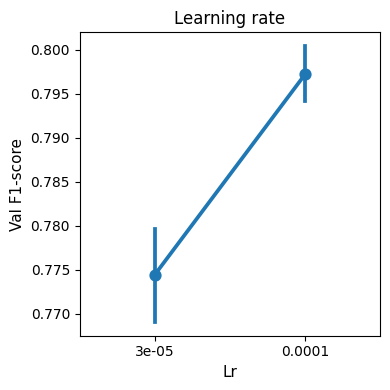

In [328]:
#Lr
plt.figure(figsize=(4,4))
sns.pointplot(data = results_on_validation_set_New, x = 'lr', y = 'val_f1', errorbar='ci')
#plt.xscale('log')
plt.tick_params(axis = 'both', which = 'major', labelsize = 10)
plt.ylabel('Val F1-score', size = 11)
plt.xlabel('Lr', size = 11)
plt.title('Learning rate')
plt.tight_layout()

In [331]:
st.spearmanr(results_on_validation_set_New['lr'],results_on_validation_set_New['val_f1'])

SignificanceResult(statistic=np.float64(0.5482707496298705), pvalue=np.float64(9.053426309031652e-11))

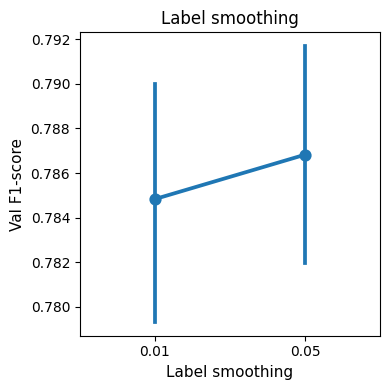

In [329]:
#label smoothing
plt.figure(figsize=(4,4))
sns.pointplot(data = results_on_validation_set_New, x = 'label_smoothing', y = 'val_f1', errorbar='ci')
#plt.xscale('log')
plt.tick_params(axis = 'both', which = 'major', labelsize = 10)
plt.ylabel('Val F1-score', size = 11)
plt.xlabel('Label smoothing', size = 11)
plt.title('Label smoothing')
plt.tight_layout()

In [330]:
st.spearmanr(results_on_validation_set_New['label_smoothing'],results_on_validation_set_New['val_f1'])

SignificanceResult(statistic=np.float64(0.04354410078236357), pvalue=np.float64(0.6367604352704771))

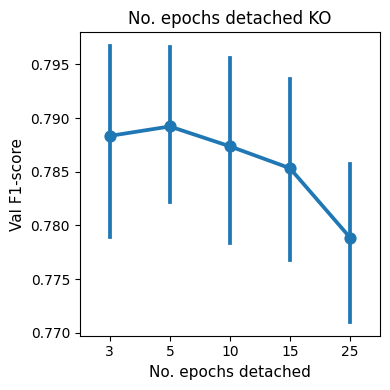

In [332]:
#detach ko epochs
plt.figure(figsize=(4,4))
sns.pointplot(data = results_on_validation_set_New, x = 'detach_ko_epochs', y = 'val_f1', errorbar='ci')
#plt.xscale('log')
plt.tick_params(axis = 'both', which = 'major', labelsize = 10)
plt.ylabel('Val F1-score', size = 11)
plt.xlabel('No. epochs detached', size = 11)
plt.title('No. epochs detached KO')
plt.tight_layout()

In [333]:
st.spearmanr(results_on_validation_set_New['detach_ko_epochs'],results_on_validation_set_New['val_f1'])

SignificanceResult(statistic=np.float64(-0.18167995200035114), pvalue=np.float64(0.047040794409050284))

In [336]:
correlation_perf_hp_New = results_on_validation_set_New.merge(tuning_results_New['test_f1'], left_index= True, right_index= True)[['lr', 'proj_ko_dim', 'proj_dim','label_smoothing', 'detach_ko_epochs','val_f1','test_f1']].corr(method = 'spearman')[['val_f1','test_f1']].drop(['val_f1', 'test_f1'])
correlation_perf_hp_New.index = [re.sub('_',' ',i).capitalize() for i in correlation_perf_hp_New.index]
correlation_perf_hp_New.columns = ['Val F1', 'Test F1']

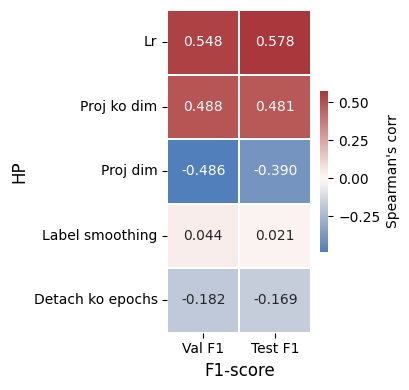

In [337]:
plt.figure(figsize=(4,4))
sns.heatmap(correlation_perf_hp_New, annot = True, fmt = '.3f',center = 0, cmap = sns.color_palette('vlag', as_cmap= True), linewidths=.1, cbar_kws={'shrink':.5, 'label':"Spearman's corr"})
plt.xlabel('F1-score', size = 12)
plt.ylabel('HP', size = 12)
plt.tight_layout()

HP interactions

In [340]:
hps_f1s_New = results_on_validation_set_New.merge(tuning_results_New['test_f1'], left_index= True, right_index= True)[['lr', 'proj_ko_dim', 'proj_dim','label_smoothing', 'detach_ko_epochs','val_f1','test_f1']]

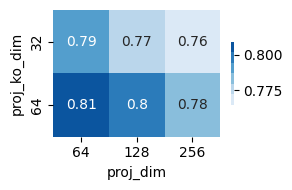

In [341]:
pivot = hps_f1s_New.pivot_table(
    values="val_f1",
    index="proj_ko_dim",
    columns="proj_dim",
    aggfunc="mean"
)
plt.figure(figsize=(3,2))
sns.heatmap(pivot, annot=True, cmap =sns.color_palette('Blues'),cbar_kws = {'shrink':.5})
plt.tight_layout()

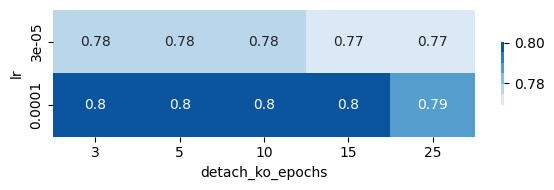

In [342]:
pivot = hps_f1s_New.pivot_table(
    values="val_f1",
    index="lr",
    columns="detach_ko_epochs",
    aggfunc="mean"
)
plt.figure(figsize=(6,2))
sns.heatmap(pivot, annot=True, cmap =sns.color_palette('Blues'),cbar_kws = {'shrink':.5})
plt.tight_layout()

Chosen model new splits

In [348]:
lowest_val_loss_New

,best_epoch,val_loss,val_acc,val_f1,patience,delta,proj_dim,proj_ko_dim,dropout_emb,dropout_ko,lr,wd,label_smoothing,detach_ko_epochs,batch_size
trial,,,,,,,,,,,,,,,
90,33,0.5299,0.8155,0.8157,15,0.001,64,64,0.1,0.2,0.0001,0.001,0.01,3,144


Provo a rilanciare modello su nuovi splits scambiando val e test 

Provo a rilanciare modello su nuovi splits tenendo val e test
python delayed_KO_chosen_MikaelSplits2.py -c mean -i ../embeddings_phylo_evo1b_overlapping/ -o delayed_KO_MikaelSplitsProva_chosenModel -s 42

Prova con diversi seed - nuovo modello

In [350]:
seeds_analysis_New = pd.read_csv('/data/users/sofia/england/TwoTowers/delayed_KO_MikaelSplitsProva_chosenModel_seedsLog/summary_results.csv')

In [352]:
seeds_analysis_New.describe()

,Seed,Best_epoch,Train_Loss,Train_F1,Train_Acc,Val_Loss,Val_F1,Val_Acc,Val_Prec,Test_Loss,Test_F1,Test_Acc,Test_Prec
count,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,160.800000,30.40000,0.198268,0.998920,0.998913,0.537539,0.81014,0.808213,0.810380,0.463606,0.836889,0.837505,0.836974
std,274.553716,4.35562,0.023463,0.001711,0.001687,0.007778,0.00589,0.005988,0.008332,0.008200,0.005647,0.005434,0.008285
min,0.000000,24.00000,0.162276,0.994500,0.994600,0.526271,0.79890,0.796300,0.795000,0.448622,0.826508,0.827138,0.821235
25%,13.500000,27.00000,0.179732,0.999050,0.999000,0.531435,0.80545,0.803700,0.804300,0.457742,0.833200,0.834573,0.833152
50%,25.000000,29.00000,0.200057,0.999600,0.999600,0.535595,0.81170,0.809300,0.813100,0.464274,0.836115,0.837051,0.835688
75%,187.500000,33.50000,0.213431,0.999800,0.999800,0.542914,0.81510,0.812400,0.817200,0.468576,0.840753,0.841078,0.843197
max,1024.000000,39.00000,0.240254,1.000000,1.000000,0.551037,0.81900,0.816700,0.819600,0.480676,0.847827,0.846964,0.850749


<Axes: xlabel='Best_epoch'>

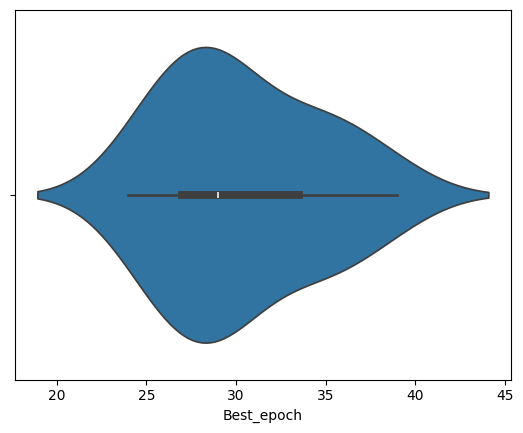

In [354]:
sns.violinplot(data = seeds_analysis_New, x  = 'Best_epoch')

In [355]:
seeds_analysis_melted_New = pd.melt(seeds_analysis_New.drop('Best_epoch', axis = 1), id_vars = ['Seed'])
seeds_analysis_melted_New[['set','metric']] = seeds_analysis_melted_New['variable'].str.split('_', n=1, expand=True)

In [357]:
seeds_analysis_melted_New

,Seed,variable,value,set,metric
0,0,Train_Loss,0.174553,Train,Loss
1,1,Train_Loss,0.240254,Train,Loss
2,5,Train_Loss,0.201604,Train,Loss
3,12,Train_Loss,0.195987,Train,Loss
4,15,Train_Loss,0.177943,Train,Loss
...,...,...,...,...,...
160,150,Test_Prec,0.833896,Test,Prec
161,225,Test_Prec,0.841708,Test,Prec
162,333,Test_Prec,0.835688,Test,Prec
163,444,Test_Prec,0.824758,Test,Prec


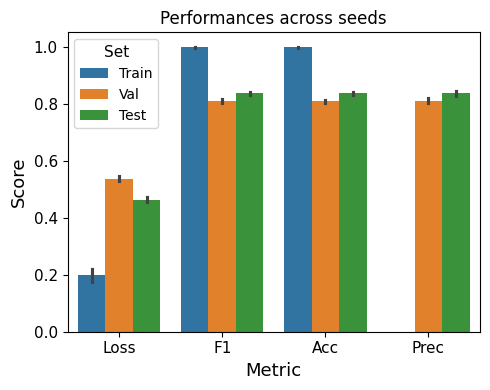

In [362]:
plt.figure(figsize = (5,4))
sns.barplot(data = seeds_analysis_melted_New, y = 'value', x = 'metric', errorbar='sd', hue = 'set')
plt.xlabel('Metric', size = 13)
plt.ylabel('Score', size = 13)
plt.tick_params(which = 'major', axis = 'both', labelsize = 11)
plt.legend(title = 'Set', title_fontsize=11)
plt.title('Performances across seeds')
plt.tight_layout()

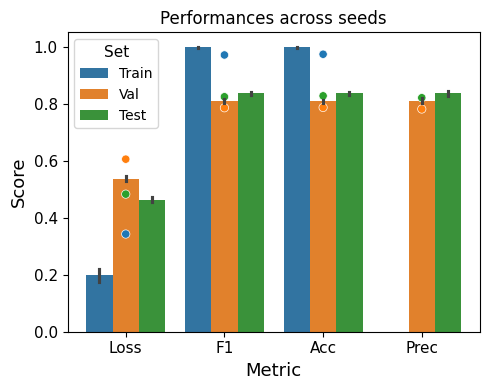

In [359]:
plt.figure(figsize = (5,4))
sns.barplot(data = seeds_analysis_melted_New, y = 'value', x = 'metric', errorbar='sd', hue = 'set')
sns.scatterplot(data = performances_MikaelSplits, y = 'value', x = 'metric', hue = 'set', legend=None) 
#Modello vecchio su questi splits
plt.xlabel('Metric', size = 13)
plt.ylabel('Score', size = 13)
plt.tick_params(which = 'major', axis = 'both', labelsize = 11)
plt.legend(title = 'Set', title_fontsize=11)
plt.title('Performances across seeds')
plt.tight_layout()